# Kommentar-Sentiment Vergleich

Dieses Notebook wertet die berechneten Kommentar-Sentiment-Ergebnisse auf Kommentar- und Video-Ebene aus.


In [16]:
from pathlib import Path
from math import sqrt

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.stats import chi2_contingency, kruskal, mannwhitneyu, spearmanr

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

COLOR_AI = "#2A9D8F"
COLOR_REAL = "#B85C7A"
PALETTE = {"VI": COLOR_AI, "RI": COLOR_REAL}
TYPE_LABELS = {"KI": "VI", "Real": "RI", "VI": "VI", "RI": "RI"}
TYPE_NOTE = "VI = AI-generierte Videos; RI = reale Videos"


def cohens_d(group_a, group_b):
    a = pd.Series(group_a).dropna().to_numpy()
    b = pd.Series(group_b).dropna().to_numpy()
    if len(a) < 2 or len(b) < 2:
        return np.nan
    pooled_var = ((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1)) / (len(a) + len(b) - 2)
    return (a.mean() - b.mean()) / sqrt(pooled_var) if pooled_var > 0 else np.nan


def p_text(p_value):
    return "signifikant" if pd.notna(p_value) and p_value < 0.05 else "nicht signifikant"


def d_interpretation(d_value):
    abs_d = abs(d_value)
    if abs_d < 0.2:
        return "vernachlässigbar klein"
    if abs_d < 0.5:
        return "klein"
    if abs_d < 0.8:
        return "mittel"
    return "groß"


def rho_interpretation(rho_value):
    abs_rho = abs(rho_value)
    if abs_rho < 0.1:
        return "praktisch kein Zusammenhang"
    if abs_rho < 0.3:
        return "schwacher Zusammenhang"
    if abs_rho < 0.5:
        return "mittlerer Zusammenhang"
    return "starker Zusammenhang"


In [17]:
BASE_DIR = Path.cwd().resolve().parents[1]
COMMENT_RESULTS_CSV = BASE_DIR / "comments" / "results" / "02_comment_sentiment_results.csv"
VIDEO_LEVEL_CSV = BASE_DIR / "comments" / "results" / "02_comment_sentiment_video_level.csv"


In [18]:
comments_df = pd.read_csv(COMMENT_RESULTS_CSV)
video_level_df = pd.read_csv(VIDEO_LEVEL_CSV)
comments_df["Typ_plot"] = comments_df["Typ"].map(TYPE_LABELS).fillna(comments_df["Typ"])
video_level_df["Typ_plot"] = video_level_df["Typ"].map(TYPE_LABELS).fillna(video_level_df["Typ"])
comment_group_summary = comments_df.groupby("Typ").agg(n=("comment_id","count"), sentiment_index_M=("sentiment_index","mean"), sentiment_index_SD=("sentiment_index","std"), sentiment_index_Md=("sentiment_index","median")).round(4).reset_index()
ki = comments_df.loc[comments_df["Typ"]=="KI","sentiment_index"]
real = comments_df.loc[comments_df["Typ"]=="Real","sentiment_index"]
comment_u, comment_p = mannwhitneyu(ki, real, alternative="two-sided")
comment_d = cohens_d(ki, real)
label_share_df = comments_df.groupby(["Typ_plot","sentiment_label_de"]).size().rename("Anzahl").reset_index()
label_share_df["Anteil_prozent"] = label_share_df.groupby("Typ_plot")["Anzahl"].transform(lambda s: 100*s/s.sum())
ct = pd.crosstab(comments_df["Typ"], comments_df["sentiment_label_de"])
chi2, chi2_p, chi2_df, _ = chi2_contingency(ct)
video_group_summary = video_level_df.groupby("Typ").agg(Videos=("video_id","count"), Kommentare_M=("comment_count","mean"), sentiment_index_M=("sentiment_index_mean","mean"), sentiment_index_SD=("sentiment_index_mean","std"), sentiment_index_Md=("sentiment_index_mean","median")).round(4).reset_index()
ki_v = video_level_df.loc[video_level_df["Typ"]=="KI","sentiment_index_mean"]
real_v = video_level_df.loc[video_level_df["Typ"]=="Real","sentiment_index_mean"]
video_u, video_p = mannwhitneyu(ki_v, real_v, alternative="two-sided")
video_d = cohens_d(ki_v, real_v)
video_corr_df = video_level_df.dropna(subset=["video_engagement_rate"]).copy()
rho_all, p_all = spearmanr(video_corr_df["sentiment_index_mean"], video_corr_df["video_engagement_rate"], nan_policy="omit")
rho_ki, p_ki = spearmanr(video_corr_df.loc[video_corr_df["Typ"]=="KI","sentiment_index_mean"], video_corr_df.loc[video_corr_df["Typ"]=="KI","video_engagement_rate"], nan_policy="omit")
rho_real, p_real = spearmanr(video_corr_df.loc[video_corr_df["Typ"]=="Real","sentiment_index_mean"], video_corr_df.loc[video_corr_df["Typ"]=="Real","video_engagement_rate"], nan_policy="omit")
display(comment_group_summary)
display(video_group_summary)


,Typ,n,sentiment_index_M,sentiment_index_SD,sentiment_index_Md
0,KI,14576,0.0448,0.5597,0.0159
1,Real,18095,0.0944,0.6322,0.0444


,Typ,Videos,Kommentare_M,sentiment_index_M,sentiment_index_SD,sentiment_index_Md
0,KI,238,61.2437,0.2830,0.4222,0.1624
1,Real,640,28.2734,0.4351,0.4255,0.5009


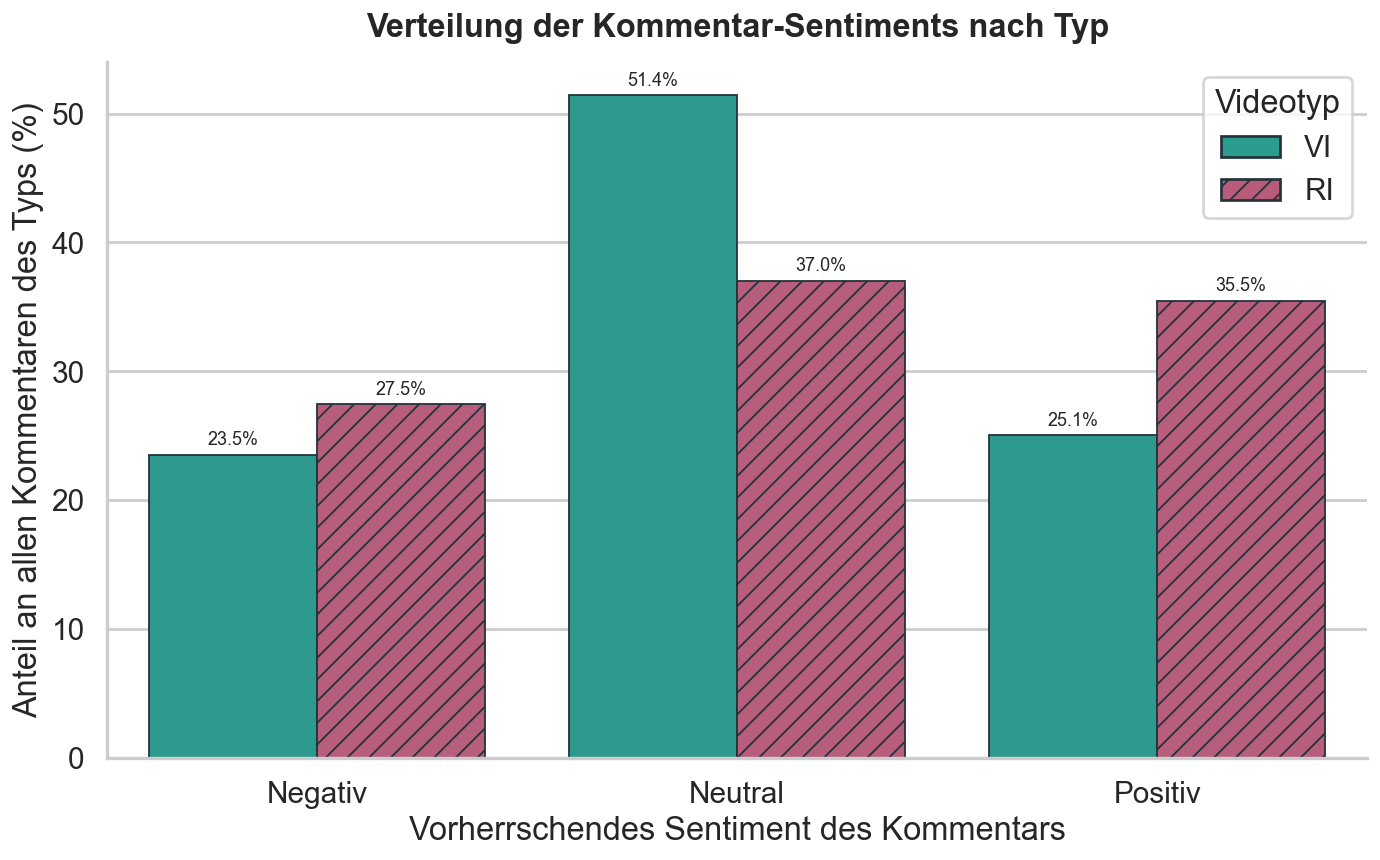

In [19]:
PALETTE_COLOR = PALETTE

fig, ax1 = plt.subplots(figsize=(10.5, 6.5), constrained_layout=True)

plot_df = label_share_df.copy()
plot_df["sentiment_label_de"] = pd.Categorical(plot_df["sentiment_label_de"], categories=["Negativ", "Neutral", "Positiv"], ordered=True)
sns.barplot(data=plot_df, x="sentiment_label_de", y="Anteil_prozent", hue="Typ_plot", hue_order=["VI", "RI"], palette=PALETTE_COLOR, saturation=0.95, edgecolor="#24323A", linewidth=1.0, ax=ax1)
ax1.set_title("Verteilung der Kommentar-Sentiments nach Typ", pad=14, weight="semibold")
ax1.set_xlabel("Vorherrschendes Sentiment des Kommentars")
ax1.set_ylabel("Anteil an allen Kommentaren des Typs (%)")
for container, hatch in zip(ax1.containers, ["", "//"]):
    for bar in container:
        bar.set_hatch(hatch)
    ax1.bar_label(container, fmt="%.1f%%", padding=3, fontsize=10)
bar_legend = [
    Patch(facecolor=COLOR_AI, edgecolor="#24323A", label="VI"),
    Patch(facecolor=COLOR_REAL, edgecolor="#24323A", hatch="//", label="RI"),
]
ax1.legend(handles=bar_legend, title="Videotyp", frameon=True)

sns.despine(ax=ax1, top=True, right=True)
#fig.text(0.01, 0.01, TYPE_NOTE, ha="left", va="bottom", fontsize=10, color="#5A5A5A")
plt.show()


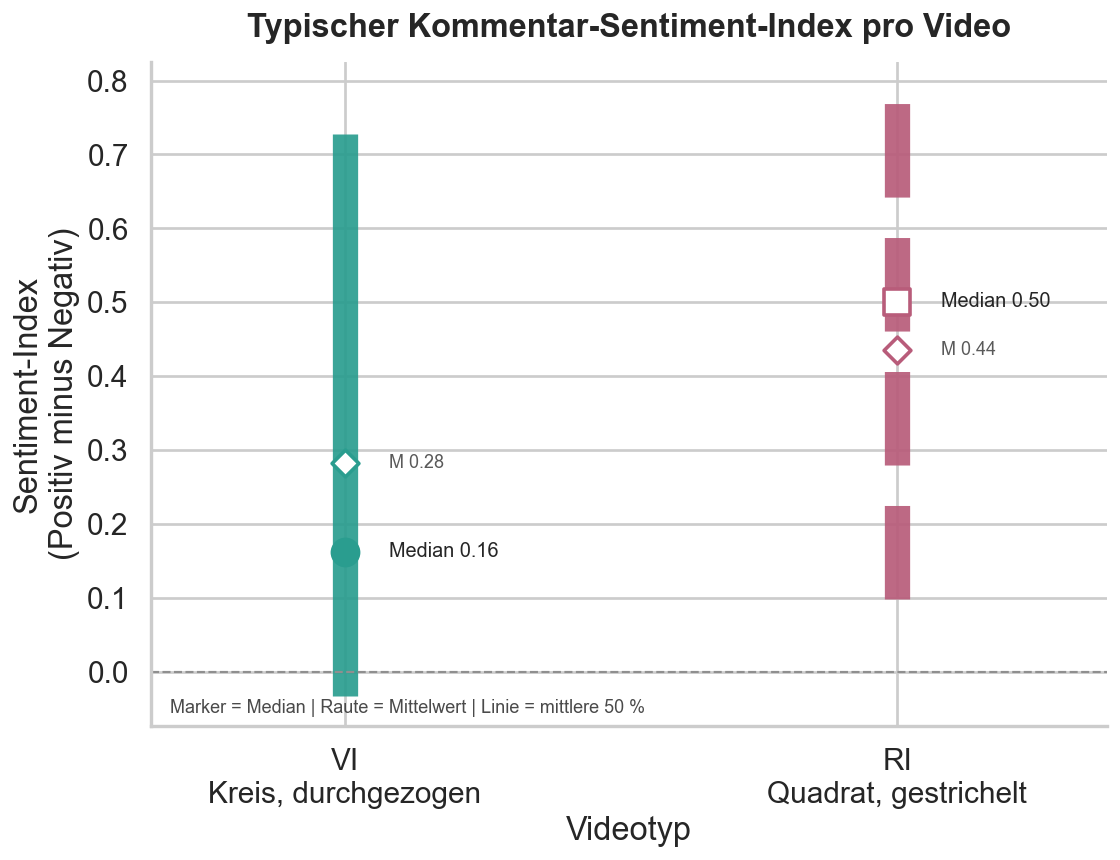

In [5]:
summary_plot_df = video_level_df.groupby("Typ_plot")["sentiment_index_mean"].agg(Q1=lambda s:s.quantile(0.25), Median="median", Q3=lambda s:s.quantile(0.75), Mittelwert="mean").reindex(["VI", "RI"]).reset_index()

fig, ax2 = plt.subplots(figsize=(8.5, 6.5), constrained_layout=True)
for x, row in enumerate(summary_plot_df.to_dict("records")):
    typ = row["Typ_plot"]
    color = PALETTE[typ]
    linestyle = "-" if typ == "VI" else "--"
    marker = "o" if typ == "VI" else "s"
    ax2.vlines(x, row["Q1"], row["Q3"], color=color, linewidth=14, alpha=0.92, linestyles=linestyle)
    ax2.scatter(x, row["Median"], color=color if typ == "VI" else "white", edgecolor=color, linewidth=2, marker=marker, s=210, zorder=4)
    ax2.scatter(x, row["Mittelwert"], color="white", edgecolor=color, linewidth=2, marker="D", s=110, zorder=5)
    ax2.text(x + 0.08, row["Median"], f"Median {row['Median']:.2f}", va="center", fontsize=11)
    ax2.text(x + 0.08, row["Mittelwert"], f"M {row['Mittelwert']:.2f}", va="center", fontsize=10, color="#5A5A5A")
ax2.axhline(0, color="#8F8F8F", linestyle="--", linewidth=1.2)
ax2.set_xticks([0, 1], ["VI\nKreis, durchgezogen", "RI\nQuadrat, gestrichelt"])
ax2.set_xlim(-0.35, 1.38)
ax2.set_title("Typischer Kommentar-Sentiment-Index pro Video", pad=14, weight="semibold")
ax2.set_xlabel("Videotyp")
ax2.set_ylabel("Sentiment-Index\n(Positiv minus Negativ)")
ax2.text(0.02, 0.02, "Marker = Median | Raute = Mittelwert | Linie = mittlere 50 %", transform=ax2.transAxes, fontsize=10, color="#4A4A4A")
#fig.text(0.01, 0.01, TYPE_NOTE, ha="left", va="bottom", fontsize=10, color="#5A5A5A")
sns.despine(ax=ax2, top=True, right=True)
plt.show()


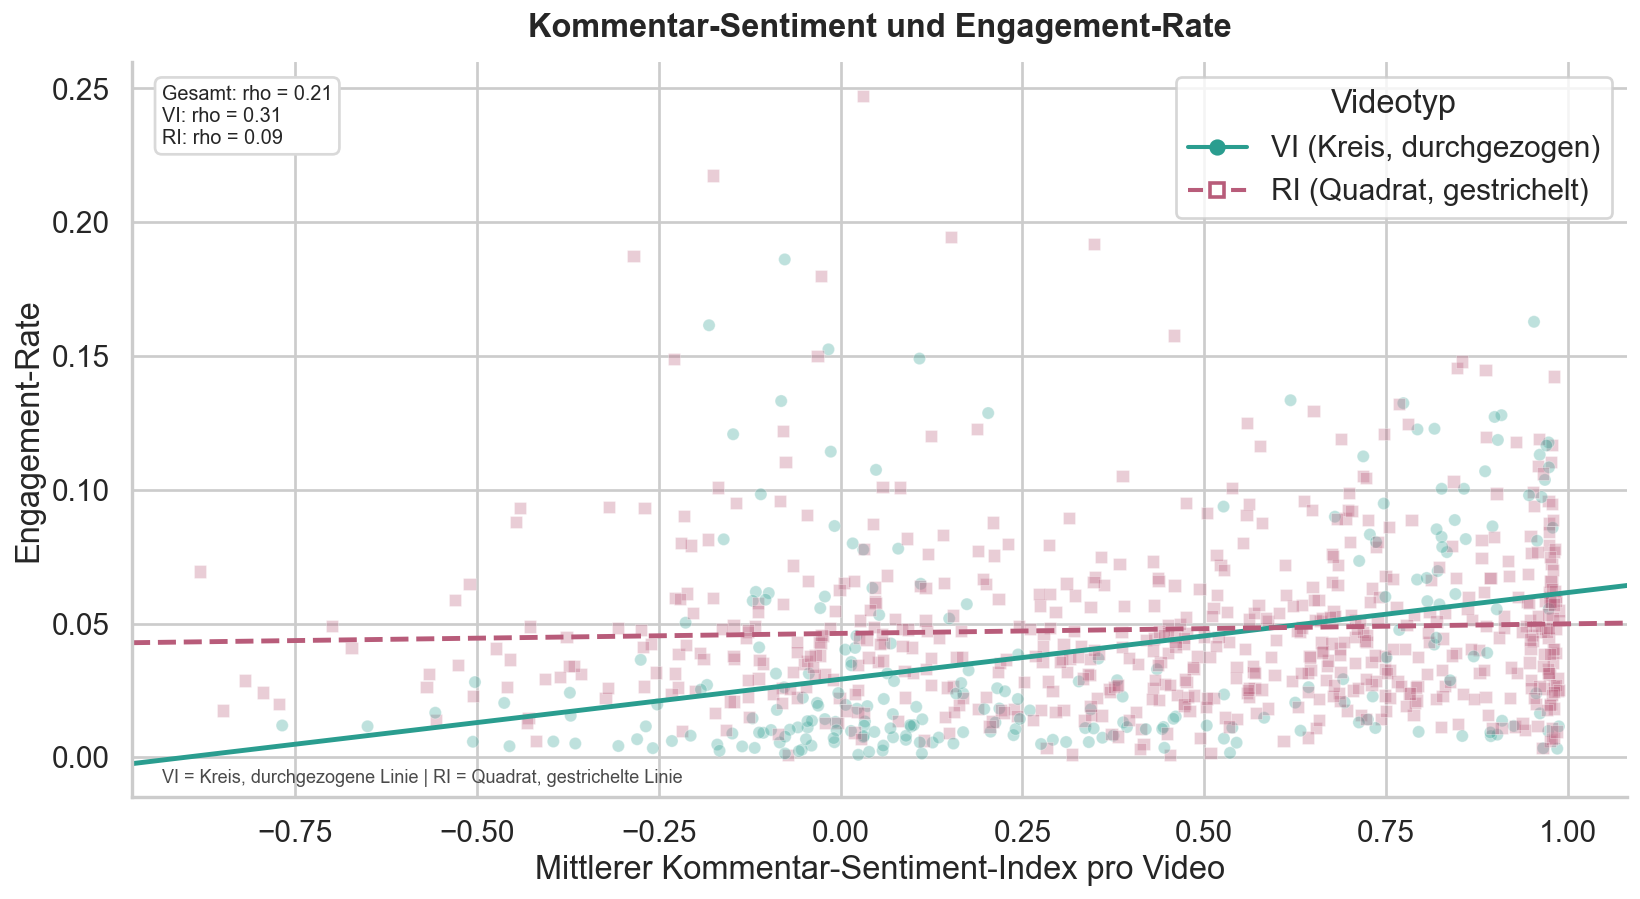

In [6]:
fig, ax3 = plt.subplots(figsize=(12.5, 6.8), constrained_layout=True)
sns.scatterplot(data=video_corr_df, x="sentiment_index_mean", y="video_engagement_rate", hue="Typ_plot", hue_order=["VI", "RI"], style="Typ_plot", style_order=["VI", "RI"], markers={"VI": "o", "RI": "s"}, palette=PALETTE, alpha=0.30, s=46, ax=ax3)
for typ, color, linestyle in [("VI", COLOR_AI, "-"), ("RI", COLOR_REAL, "--")]:
    subset = video_corr_df[video_corr_df["Typ_plot"] == typ]
    if len(subset) >= 2:
        sns.regplot(data=subset, x="sentiment_index_mean", y="video_engagement_rate", scatter=False, ci=None, truncate=False, line_kws={"color": color, "linewidth": 2.7, "linestyle": linestyle}, ax=ax3)
ax3.set_title("Kommentar-Sentiment und Engagement-Rate", pad=14, weight="semibold")
ax3.set_xlabel("Mittlerer Kommentar-Sentiment-Index pro Video")
ax3.set_ylabel("Engagement-Rate")
stats_text = f"Gesamt: rho = {rho_all:.2f}\nVI: rho = {rho_ki:.2f}\nRI: rho = {rho_real:.2f}"
ax3.text(0.02, 0.97, stats_text, transform=ax3.transAxes, va="top", fontsize=11, bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#D9D9D9"})
ax3.text(0.02, 0.02, "VI = Kreis, durchgezogene Linie | RI = Quadrat, gestrichelte Linie", transform=ax3.transAxes, fontsize=10, color="#4A4A4A")
engagement_legend = [
    Line2D([0], [0], color=COLOR_AI, marker="o", linestyle="-", markersize=8, label="VI (Kreis, durchgezogen)"),
    Line2D([0], [0], color=COLOR_REAL, marker="s", markerfacecolor="white", markeredgewidth=2, linestyle="--", markersize=8, label="RI (Quadrat, gestrichelt)"),
]
ax3.legend(handles=engagement_legend, title="Videotyp", frameon=True, loc="upper right")
#fig.text(0.01, 0.01, TYPE_NOTE, ha="left", va="bottom", fontsize=10, color="#5A5A5A")
sns.despine(ax=ax3, top=True, right=True)
plt.show()


In [7]:
ki_row = comment_group_summary.loc[comment_group_summary["Typ"]=="KI"].iloc[0]
real_row = comment_group_summary.loc[comment_group_summary["Typ"]=="Real"].iloc[0]
ki_video_row = video_group_summary.loc[video_group_summary["Typ"]=="KI"].iloc[0]
real_video_row = video_group_summary.loc[video_group_summary["Typ"]=="Real"].iloc[0]
print("Kommentar-Level")
print(f"VI: n = {int(ki_row['n'])}, M = {ki_row['sentiment_index_M']:.3f}, SD = {ki_row['sentiment_index_SD']:.3f}, Md = {ki_row['sentiment_index_Md']:.3f}")
print(f"RI: n = {int(real_row['n'])}, M = {real_row['sentiment_index_M']:.3f}, SD = {real_row['sentiment_index_SD']:.3f}, Md = {real_row['sentiment_index_Md']:.3f}")
print(f"Gruppenunterschied: U = {comment_u:.2f}, p = {comment_p:.4f}. Der Unterschied ist {p_text(comment_p)}. Effektgröße: {d_interpretation(comment_d)} (d = {comment_d:.3f}).")
print(f"Label-Verteilung: chi2 = {chi2:.2f}, df = {chi2_df}, p = {chi2_p:.4f}. Die Verteilung ist {p_text(chi2_p)} unterschiedlich.")
print()
print("Video-Level")
print(f"VI: n = {int(ki_video_row['Videos'])}, M = {ki_video_row['sentiment_index_M']:.3f}, SD = {ki_video_row['sentiment_index_SD']:.3f}, Md = {ki_video_row['sentiment_index_Md']:.3f}")
print(f"RI: n = {int(real_video_row['Videos'])}, M = {real_video_row['sentiment_index_M']:.3f}, SD = {real_video_row['sentiment_index_SD']:.3f}, Md = {real_video_row['sentiment_index_Md']:.3f}")
print(f"Gruppenunterschied: U = {video_u:.2f}, p = {video_p:.4f}. Der Unterschied ist {p_text(video_p)}. Effektgröße: {d_interpretation(video_d)} (d = {video_d:.3f}).")
print(f"Zusammenhang mit Engagement gesamt: rho = {rho_all:.3f}, p = {p_all:.4f}. Der Befund ist {p_text(p_all)} und entspricht {rho_interpretation(rho_all)}.")
print(f"Zusammenhang mit Engagement nur VI: rho = {rho_ki:.3f}, p = {p_ki:.4f}.")
print(f"Zusammenhang mit Engagement nur RI: rho = {rho_real:.3f}, p = {p_real:.4f}.")


Kommentar-Level
VI: n = 14576, M = 0.045, SD = 0.560, Md = 0.016
RI: n = 18095, M = 0.094, SD = 0.632, Md = 0.044
Gruppenunterschied: U = 126870352.00, p = 0.0000. Der Unterschied ist signifikant. Effektgröße: vernachlässigbar klein (d = -0.083).
Label-Verteilung: chi2 = 717.23, df = 2, p = 0.0000. Die Verteilung ist signifikant unterschiedlich.

Video-Level
VI: n = 238, M = 0.283, SD = 0.422, Md = 0.162
RI: n = 640, M = 0.435, SD = 0.425, Md = 0.501
Gruppenunterschied: U = 59987.00, p = 0.0000. Der Unterschied ist signifikant. Effektgröße: klein (d = -0.358).
Zusammenhang mit Engagement gesamt: rho = 0.209, p = 0.0000. Der Befund ist signifikant und entspricht schwacher Zusammenhang.
Zusammenhang mit Engagement nur VI: rho = 0.306, p = 0.0000.
Zusammenhang mit Engagement nur RI: rho = 0.093, p = 0.0191.
